# 📚 Hybrid Book Recommender : LightGCN + BERT
## 8INF974 — Projet 3

### Idée centrale
Ce notebook fusionne deux approches complémentaires :
- **LightGCN** (collègue A) : modélise les interactions user→livre dans un graphe biparti
- **BERT/SBERT** (collègue B) : encode les descriptions textuelles des livres

### Architecture hybride
```
descriptions livres
      │
   SBERT encode
      │
      ▼
 embed_books (384-dim)  ←── initialise les nœuds livres
      │
      ▼
  LightGCN (graphe user-livre)
      │
      ▼
 embeddings enrichis par le contexte collaboratif
      │
      ▼
  Recommandations : pertinentes sémantiquement ET collaborativement
```

### Dataset : Amazon Books Reviews (Kaggle)
- `Books_ratings.csv` : `Id`, `Title`, `User_id`, `review/score`, ...
- `books_data.csv`    : `Title`, `description`, `authors`, `categories`, ...
- Clé de jointure    : **Title**

### Pipeline
1. Chargement & fusion des deux fichiers CSV
2. Prétraitement & filtres de densité
3. Encodage BERT des descriptions → features initiales des nœuds livres
4. Construction du graphe biparti user-livre
5. LightGCN hybride : embedding initial ≠ aléatoire pour les livres
6. Entraînement BPR + métriques Recall@K / Precision@K
7. Recommandations avec explication (similarité BERT + score GNN)

# 0. Installation & Imports

In [1]:

from preprocessing import *
import  matplotlib.pyplot as plt

# 1. Chargement et Anayse du dataset prétraité

In [2]:
df = load_and_preprocess(use_cache=True)


Cache trouvé → chargement rapide (C:\UQACode\Hiver2026\Atelier II-IA\8INF974_Projet3\book_recommender\Hybrid method\cache\preprocessed_cache.parquet)
  6,625 users | 2,909 livres | 173,010 interactions


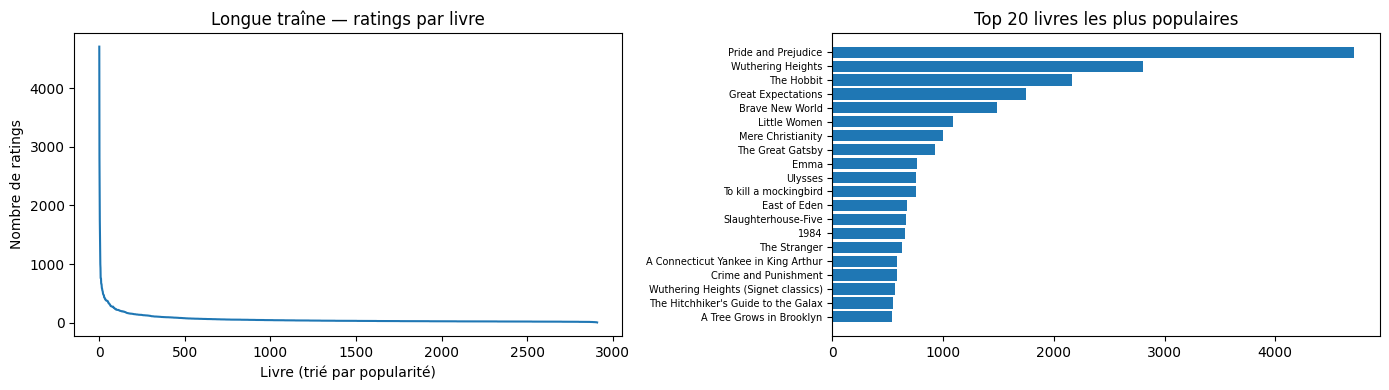

Top 5% des livres concentre 34.2% des ratings


In [3]:
# ── Biais de popularité ──────────────────────────────────────────────────────
book_pop = df['title'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(len(book_pop)), book_pop.values)
axes[0].set_title('Longue traîne — ratings par livre')
axes[0].set_xlabel('Livre (trié par popularité)')
axes[0].set_ylabel('Nombre de ratings')

top_n = 20
axes[1].barh(range(top_n), book_pop.head(top_n).values)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([t[:35] for t in book_pop.head(top_n).index], fontsize=7)
axes[1].set_title(f'Top {top_n} livres les plus populaires')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

top5 = int(len(book_pop) * 0.05)
print(f"Top 5% des livres concentre {book_pop.head(top5).sum()/book_pop.sum():.1%} des ratings")